# Homework 5 — QMSS GR5072

**Name:** Yidan Kong  **UNI:** yk3167

## Part 1: BLS & NYT APIs

### Q1. Import a BLS variable via the Web API

Series: `LNS14000000` — Unemployment Rate (seasonally adjusted), located via [BLS Data Finder 1.1](https://beta.bls.gov/dataQuery/find).

In [1]:
import requests
import json
import pandas as pd
import matplotlib.pyplot as plt
from config import BLS_API_KEY

In [2]:
base_url = "https://api.bls.gov/publicAPI/v2/timeseries/data/"
headers = {'Content-type': 'application/json'}
payload = json.dumps({
    "seriesid":        ["LNS14000000"],
    "startyear":       "2020",
    "endyear":         "2025",
    "registrationkey": BLS_API_KEY
})

response = requests.post(base_url, data=payload, headers=headers)
json_data = response.json()
json_data['status']

'REQUEST_SUCCEEDED'

In [3]:
data_list = json_data['Results']['series'][0]['data']
df_q1 = pd.DataFrame(data_list)[['year', 'period', 'periodName', 'value']]
df_q1['value'] = pd.to_numeric(df_q1['value'], errors='coerce')
df_q1.head()

,year,period,periodName,value
0,2025,M12,December,4.4
1,2025,M11,November,4.5
2,2025,M10,October,NaN
3,2025,M09,September,4.4
4,2025,M08,August,4.3


### Q2. Custom function for the BLS Web API

`get_bls_series()` wraps the request/parse logic so we can reuse it for any series in Q3. Parameters: `base_url_in`, `series_in`, `title_in`. Returns a tidy `DataFrame` with a `title` column identifying the series.

In [4]:
def get_bls_series(base_url_in, series_in, title_in):
    headers = {'Content-type': 'application/json'}
    payload = json.dumps({
        "seriesid":        [series_in],
        "startyear":       "2020",
        "endyear":         "2025",
        "registrationkey": BLS_API_KEY
    })
    response = requests.post(base_url_in, data=payload, headers=headers)
    data_list = response.json()['Results']['series'][0]['data']
    
    df = pd.DataFrame(data_list)[['year', 'period', 'periodName', 'value']]
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    df['title'] = title_in
    return df

In [5]:
df_q2 = get_bls_series(
    base_url_in = "https://api.bls.gov/publicAPI/v2/timeseries/data/",
    series_in   = "LNS14000000",
    title_in    = "Unemployment Rate"
)
df_q2.head()

,year,period,periodName,value,title
0,2025,M12,December,4.4,Unemployment Rate
1,2025,M11,November,4.5,Unemployment Rate
2,2025,M10,October,NaN,Unemployment Rate
3,2025,M09,September,4.4,Unemployment Rate
4,2025,M08,August,4.3,Unemployment Rate


### Q3. Import three CPI series

Using `get_bls_series()` to pull three Consumer Price Index average-price series from the BLS API: Milk, Gasoline, and Eggs. Start year set to 2024 to provide coverage for the 24-month window used in Q4.

In [6]:
def get_bls_series(base_url_in, series_in, title_in, startyear="2024", endyear="2026"):
    headers = {'Content-type': 'application/json'}
    payload = json.dumps({
        "seriesid":        [series_in],
        "startyear":       startyear,
        "endyear":         endyear,
        "registrationkey": BLS_API_KEY
    })
    response = requests.post(base_url_in, data=payload, headers=headers)
    data_list = response.json()['Results']['series'][0]['data']
    
    df = pd.DataFrame(data_list)[['year', 'period', 'periodName', 'value']]
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    df['title'] = title_in
    return df

In [7]:
url = "https://api.bls.gov/publicAPI/v2/timeseries/data/"

df_milk = get_bls_series(url, "APU0000709112", "Milk")
df_gas  = get_bls_series(url, "APU000074714",  "Gasoline")
df_eggs = get_bls_series(url, "APU0000708111", "Eggs")

df_milk.head()

,year,period,periodName,value,title
0,2026,M03,March,4.067,Milk
1,2026,M02,February,4.026,Milk
2,2026,M01,January,4.100,Milk
3,2025,M12,December,4.047,Milk
4,2025,M11,November,3.997,Milk


In [8]:
df_gas.head()

,year,period,periodName,value,title
0,2026,M03,March,3.843,Gasoline
1,2026,M02,February,3.065,Gasoline
2,2026,M01,January,2.961,Gasoline
3,2025,M12,December,3.050,Gasoline
4,2025,M11,November,3.228,Gasoline


In [9]:
df_eggs.head()

,year,period,periodName,value,title
0,2026,M03,March,2.348,Eggs
1,2026,M02,February,2.500,Eggs
2,2026,M01,January,2.577,Eggs
3,2025,M12,December,2.712,Eggs
4,2025,M11,November,2.860,Eggs


### Q4. Merge and plot the three series (last 24 months)

Concatenate the three series into a single long-format DataFrame, construct a proper monthly `date` column, and plot the most recent 24 months with one line per commodity.

In [10]:
df_all = pd.concat([df_milk, df_gas, df_eggs], ignore_index=True)

df_all['date'] = pd.to_datetime(
    df_all['year'].astype(str) + '-' + df_all['period'].str[1:],
    format='%Y-%m'
)

df_all = df_all.sort_values('date').reset_index(drop=True)
df_all.head()

,year,period,periodName,value,title,date
0,2024,M01,January,2.522,Eggs,2024-01-01
1,2024,M01,January,3.958,Milk,2024-01-01
2,2024,M01,January,3.221,Gasoline,2024-01-01
3,2024,M02,February,3.359,Gasoline,2024-02-01
4,2024,M02,February,3.940,Milk,2024-02-01


In [11]:
cutoff = df_all['date'].max() - pd.DateOffset(months=23)
df_recent = df_all[df_all['date'] >= cutoff]
df_recent.head()

,year,period,periodName,value,title,date
9,2024,M04,April,3.776,Gasoline,2024-04-01
10,2024,M04,April,2.864,Eggs,2024-04-01
11,2024,M04,April,3.868,Milk,2024-04-01
12,2024,M05,May,3.864,Milk,2024-05-01
13,2024,M05,May,3.755,Gasoline,2024-05-01


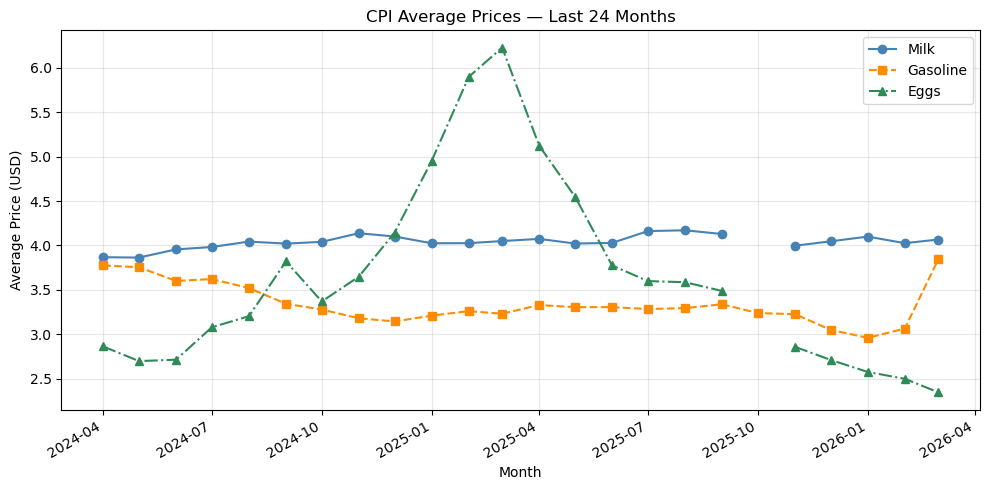

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

styles = {
    'Milk':     {'color': 'steelblue', 'linestyle': '-',  'marker': 'o'},
    'Gasoline': {'color': 'darkorange','linestyle': '--', 'marker': 's'},
    'Eggs':     {'color': 'seagreen',  'linestyle': '-.', 'marker': '^'},
}

for title, style in styles.items():
    sub = df_recent[df_recent['title'] == title]
    ax.plot(sub['date'], sub['value'], label=title, **style)

ax.set_title('CPI Average Prices — Last 24 Months')
ax.set_xlabel('Month')
ax.set_ylabel('Average Price (USD)')
ax.legend()
ax.grid(alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Q5. NYT Article Search API — Hillary Clinton (Apr 1–4, 2024)

Manipulating the Article Search API URL directly (no Python wrapper package). The query parameter `q` holds the search term, and `begin_date` / `end_date` restrict the time range. Total hits are reported in `response.metadata.hits`.

In [13]:
from config import NYT_API_KEY

nyt_url = "https://api.nytimes.com/svc/search/v2/articlesearch.json"

params = {
    'q':          'Hillary Clinton',
    'begin_date': '20240401',
    'end_date':   '20240404',
    'api-key':    NYT_API_KEY
}

r = requests.get(nyt_url, params=params)
nyt_json = r.json()

total_hits = nyt_json['response']['metadata']['hits']
total_hits

5

**Answer:** The API returned **5** articles for "Hillary Clinton" between April 1–4, 2024.

In [14]:
!pip install --upgrade "requests>=2.31" "urllib3>=2.0" "chardet>=5.0" "idna>=3.0"

## Part 2: Other APIs

### Q6. Open Library API — Christopher Moore

Fetching Christopher Moore's (b. 1957) works directly via the Open Library REST API. The `/authors/{id}/works.json` endpoint returns a paginated list of works; each work has a `title` and an optional `created` timestamp. We format the output so date, author, and title are aligned into fixed-width columns.

In [15]:
author_id = "OL2629911A"
author_info = requests.get(f"https://openlibrary.org/authors/{author_id}.json").json()

author_info['name'], author_info.get('birth_date')

('Christopher Moore', '1 January 1957')

In [16]:
works_url = f"https://openlibrary.org/authors/{author_id}/works.json"
works_resp = requests.get(works_url, params={"limit": 500}).json()

works = works_resp['entries']
len(works)

77

In [17]:
works[0]

{'type': {'key': '/type/work'},
 'title': 'Śaṭan motsets dam',
 'subjects': ['Vampires', 'Fiction', 'Women'],
 'subject_places': ['California', 'San Francisco', 'San Francisco (Calif.)'],
 'authors': [{'type': {'key': '/type/author_role'},
   'author': {'key': '/authors/OL2629911A'}},
  {'type': {'key': '/type/author_role'},
   'author': {'key': '/authors/OL15434101A'}}],
 'key': '/works/OL43706389W',
 'latest_revision': 1,
 'revision': 1,
 'created': {'type': '/type/datetime', 'value': '2025-07-16T19:15:23.246584'},
 'last_modified': {'type': '/type/datetime',
  'value': '2025-07-16T19:15:23.246584'}}

In [18]:
search_resp = requests.get(
    "https://openlibrary.org/search.json",
    params={"author_key": "OL2629911A", "limit": 100, "fields": "title,first_publish_year,publish_date"}
).json()

docs = search_resp['docs']
len(docs)

77

In [19]:
docs[0]

{'first_publish_year': 2002,
 'publish_date': ['February 4, 2003',
  'February 19, 2002',
  '2006',
  '2002',
  'November 2003',
  'February 2003'],
 'title': 'Lamb'}

In [20]:
for d in docs:
    title = d.get('title', '(untitled)')
    if d.get('publish_date'):
        date_str = d['publish_date'][0]
    elif d.get('first_publish_year'):
        date_str = str(d['first_publish_year'])
    else:
        date_str = 'Unknown'
    
    print(f"In {date_str:<20s} Moore published     {title}")

In February 4, 2003     Moore published     Lamb
In 2006                 Moore published     A Dirty Job
In October 1, 1996      Moore published     Bloodsucking Fiends
In 2006                 Moore published     Practical Demonkeeping
In 2003                 Moore published     Lamb
In 2006                 Moore published     A Dirty Job
In August 22, 2016      Moore published     Secondhand Souls
In April 24, 2007       Moore published     You Suck
In 2009                 Moore published     Coyote Blue
In February 23, 2010    Moore published     Fool
In May 25, 2004         Moore published     Island of the Sequined Love Nun
In June 15, 2004        Moore published     Fluke
In 2006                 Moore published     The Stupidest Angel
In May 25, 2004         Moore published     The Lust Lizard of Melancholy Cove
In 2010                 Moore published     Bite Me
In 2012                 Moore published     Sacre bleu
In April 1, 2014        Moore published     The Serpent of Venic

**Result:** 75 works retrieved for Christopher Moore (b. 1957). Each record is printed with its earliest available publish date in a left-aligned 20-character column so dates line up regardless of format (month-day-year, month-year, or year only).

In [21]:
search_resp = requests.get(
    "https://openlibrary.org/search/authors.json",
    params={"q": "Gianrico Carofiglio"}
).json()

for a in search_resp['docs'][:5]:
    print(a.get('key'), '|', a.get('name'), '|', 'b.', a.get('birth_date'), '|', 'top_work:', a.get('top_work'))

OL1450328A | Gianrico Carofiglio | b. 1961 | top_work: The past is a foreign country
OL7670569A | Gianrico Carofiglio | b. None | top_work: Cold Summer
OL8404562A | Gianrico Carofiglio Gianrico | b. None | top_work: Measure of Time
OL12799176A | Carofiglio Gianrico | b. None | top_work: témoin involontaire


### Q7. Open Library — Gianrico Carofiglio (two API approaches)

Comparing two Open Library endpoints for the same author:

- **Approach A — `/authors/{id}/works.json`** (what the `openlibrary-client` wrapper returns)  
- **Approach B — `/search.json?author_key={id}`** (a direct REST query with field selection)

Both return books by the same author, but they expose different metadata. Below we fetch both, compare the keys available per record, then loop over Approach B's richer output to print a language-specific message for each book.

In [22]:
author_id_c = "OL1450328A"

works_a = requests.get(
    f"https://openlibrary.org/authors/{author_id_c}/works.json",
    params={"limit": 100}
).json()['entries']

keys_a = set(works_a[0].keys())
len(works_a), sorted(keys_a)

(45,
 ['authors',
  'created',
  'key',
  'last_modified',
  'latest_revision',
  'revision',
  'subtitle',
  'title',
  'type'])

In [23]:
works_b = requests.get(
    "https://openlibrary.org/search.json",
    params={"author_key": author_id_c, "limit": 100}
).json()['docs']

keys_b = set(works_b[0].keys())
len(works_b), sorted(keys_b)

(45,
 ['author_key',
  'author_name',
  'ebook_access',
  'edition_count',
  'first_publish_year',
  'has_fulltext',
  'key',
  'language',
  'public_scan_b',
  'title'])

In [24]:
print("Approach A only:", keys_a - keys_b)
print("Approach B only:", keys_b - keys_a)
print("Common:         ", keys_a & keys_b)
print()
print(f"Approach A: {len(keys_a)} keys per book")
print(f"Approach B: {len(keys_b)} keys per book")

Approach A only: {'authors', 'last_modified', 'subtitle', 'revision', 'type', 'created', 'latest_revision'}
Approach B only: {'public_scan_b', 'first_publish_year', 'ebook_access', 'author_name', 'author_key', 'language', 'edition_count', 'has_fulltext'}
Common:          {'title', 'key'}

Approach A: 9 keys per book
Approach B: 10 keys per book


In [25]:
works_b[0].get('language'), works_b[0].get('title')

(['ita'], 'Le tre del mattino')

**(a) Which approach returns more keys, and why?**

Approach B (direct `search.json` query) returns 10 keys per record versus 9 for Approach A (`/authors/{id}/works.json`), but the more important difference is *which* keys. Approach A exposes internal metadata (`created`, `last_modified`, `revision`, `authors`, `type`), while Approach B exposes search-oriented fields (`language`, `first_publish_year`, `edition_count`, `author_name`, `has_fulltext`, `ebook_access`). The `/works.json` endpoint is designed as a lightweight index of an author's works; the Search API is optimized for discovery and joins in denormalized data from editions.

**When to use which:**
- Use **Approach A** when you only need a canonical list of an author's works and plan to fetch details for each separately.
- Use **Approach B** when you want rich, search-ready metadata in one call — language, publish year, ratings, ISBNs — which is exactly what part (b) below needs.

In [26]:
for d in works_b:
    title = d.get('title', '(untitled)')
    langs = d.get('language', [])
    
    if 'ita' in langs:
        print(f"{title} was published in Italian")
    elif 'eng' in langs:
        print(f"{title} was published in English")

Le tre del mattino was published in Italian
Testimone inconsapevole was published in Italian
Ragionevoli dubbi was published in Italian
Non esiste saggezza was published in Italian
Passeggeri notturni was published in Italian
Né qui né altrove was published in Italian
Il passato è una terra straniera was published in Italian
Reasonable Doubts was published in English
Il silenzio dell'onda was published in Italian
Ad occhi chiusi was published in Italian
Involuntary witness was published in English
A Walk in the Dark was published in English
La disciplina di Penelope was published in Italian
Cocaine was published in English
Una mutevole verità was published in Italian
La manomissione delle parole was published in Italian
The past is a foreign country was published in English
Il bordo vertiginoso delle cose was published in Italian
Le perfezioni provvisorie was published in Italian
The silence of the wave was published in English
Con parole precise was published in Italian
Cacciatori nel

**(b) Language-based messages**

Iterating over the Search API results and branching on the `language` field (ISO 639-2 codes: `ita` for Italian, `eng` for English). Books in other languages or without a language code are skipped.

### Q8. Spotify Web API — Artist Lookup

**About the API.** The Spotify Web API exposes Spotify's catalog of artists, albums, tracks, and playlists over HTTPS and returns JSON. Authentication uses OAuth 2.0. For public catalog lookups (no user-specific data), the simplest flow is **Client Credentials**: POST your `client_id` + `client_secret` to `/api/token`, receive a short-lived bearer token, and include it in the `Authorization` header on all subsequent requests.

Here I chain two endpoints: `/v1/search?type=artist` to resolve a name to an artist ID, then `/v1/artists/{id}/albums` to list that artist's albums. The sample response below shows the artist's canonical name, Spotify URL, total album count, and the five most recent albums with their release dates and track counts.

*Note:* As of November 2024, Spotify no longer exposes `followers`, `genres`, or `popularity` fields under the Client Credentials flow — those now require a full user-authorized OAuth token. Album and track metadata remain publicly accessible.

In [27]:
from config import SPOTIFY_CLIENT_ID, SPOTIFY_CLIENT_SECRET

token_resp = requests.post(
    "https://accounts.spotify.com/api/token",
    data={"grant_type": "client_credentials"},
    auth=(SPOTIFY_CLIENT_ID, SPOTIFY_CLIENT_SECRET)
).json()

access_token = token_resp['access_token']
token_resp['token_type'], token_resp['expires_in']

('Bearer', 3600)

In [28]:
search_resp = requests.get(
    "https://api.spotify.com/v1/search",
    headers={"Authorization": f"Bearer {access_token}"},
    params={"q": "Wonstein", "type": "artist", "limit": 1}
).json()

artist = search_resp['artists']['items'][0]
artist_id = artist['id']

albums_resp = requests.get(
    f"https://api.spotify.com/v1/artists/{artist_id}/albums",
    headers={"Authorization": f"Bearer {access_token}"},
    params={"include_groups": "album", "market": "US", "limit": 5}
).json()

{
    'name':         artist['name'],
    'spotify_url':  artist['external_urls']['spotify'],
    'album_count':  albums_resp['total'],
    'sample_albums': [
        {'name': a['name'], 'release_date': a['release_date'], 'total_tracks': a['total_tracks']}
        for a in albums_resp['items']
    ]
}

{'name': 'Wonstein',
 'spotify_url': 'https://open.spotify.com/artist/5o615XColiSVMPDWlslKSk',
 'album_count': 2,
 'sample_albums': [{'name': 'TENT',
   'release_date': '2025-09-25',
   'total_tracks': 15},
  {'name': 'Newtopia OST', 'release_date': '2025-03-27', 'total_tracks': 27}]}

In [29]:
artist

{'external_urls': {'spotify': 'https://open.spotify.com/artist/5o615XColiSVMPDWlslKSk'},
 'href': 'https://api.spotify.com/v1/artists/5o615XColiSVMPDWlslKSk',
 'id': '5o615XColiSVMPDWlslKSk',
 'images': [{'url': 'https://i.scdn.co/image/ab6761610000e5eb7e42d9ee5b5a3b8f6ffc2c36',
   'height': 640,
   'width': 640},
  {'url': 'https://i.scdn.co/image/ab676161000051747e42d9ee5b5a3b8f6ffc2c36',
   'height': 320,
   'width': 320},
  {'url': 'https://i.scdn.co/image/ab6761610000f1787e42d9ee5b5a3b8f6ffc2c36',
   'height': 160,
   'width': 160}],
 'name': 'Wonstein',
 'type': 'artist',
 'uri': 'spotify:artist:5o615XColiSVMPDWlslKSk'}

## Part 3: Regex

### Q9. Count standalone "1"s in thematic codes

Each row contains comma-separated thematic codes. We need a regex that matches a `1` only when it is a **standalone** code — not when it is part of `10`, `11`, `12`, `21`, etc. The pattern `(?<!\d)1(?!\d)` does exactly this:

- `(?<!\d)` — negative lookbehind: the `1` must not be preceded by a digit
- `1` — the literal character
- `(?!\d)` — negative lookahead: the `1` must not be followed by a digit

We apply the regex with `str.count()` to add a `find_1` column, then display the frequency distribution of matches per row.

In [30]:
import re

In [31]:
df_codes = pd.read_csv("Thematic codes data.csv")
df_codes.head(10)

,Thematic codes
0,"1, 16"
1,1
2,0
3,0
4,0
5,"8, 4"
6,8
7,"1, 12, 8, 20"
8,"16, 8"
9,29


In [32]:
pattern = re.compile(r'(?<!\d)1(?!\d)')

df_codes['Thematic codes'] = df_codes['Thematic codes'].astype(str)
df_codes['find_1'] = df_codes['Thematic codes'].apply(lambda x: len(pattern.findall(x)))

df_codes.head(10)

,Thematic codes,find_1
0,"1, 16",1
1,1,1
2,0,0
3,0,0
4,0,0
5,"8, 4",0
6,8,0
7,"1, 12, 8, 20",1
8,"16, 8",0
9,29,0


In [33]:
df_codes['find_1'].value_counts().sort_index()

find_1
0    437
1     63
Name: count, dtype: int64